In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

#file upload
file_path = "Cars Datasets 2025.csv"
df = pd.read_csv(file_path, encoding='latin-1')

print("\n=====TABLE INFORMATION=====\n")
df.info()

print("\n=====TABLE DESCRIPTION=====\n")
df.describe()


=====TABLE INFORMATION=====

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company Names              1218 non-null   object
 1   Cars Names                 1218 non-null   object
 2   Engines                    1218 non-null   object
 3   CC/Battery Capacity        1215 non-null   object
 4   HorsePower                 1218 non-null   object
 5   Total Speed                1218 non-null   object
 6   Performance(0 - 100 )KM/H  1212 non-null   object
 7   Cars Prices                1218 non-null   object
 8   Fuel Types                 1218 non-null   object
 9   Seats                      1218 non-null   object
 10  Torque                     1217 non-null   object
dtypes: object(11)
memory usage: 104.8+ KB

=====TABLE DESCRIPTION=====



,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
count,1218,1218,1218,1215,1218,1218,1212,1218,1218,1218,1217
unique,37,1201,356,311,456,114,180,535,23,19,263
top,Nissan,Macan T,I4,"2,000 cc",355 hp,250 km/h,6.5 sec,"$35,000",Petrol,5,400 Nm
freq,149,2,64,31,23,145,45,36,871,692,72


In [2]:
print(df["Fuel Types"].unique())
counters = df['Fuel Types'].value_counts()
print(counters)
df.nunique()

['plug in hyrbrid' 'Petrol' 'Diesel' 'Hybrid' 'Electric' 'Petrol/Diesel'
 'Plug-in Hybrid' 'Petrol/AWD' 'Petrol/Hybrid' 'Hydrogen' 'Diesel/Petrol'
 'Petrol/EV' 'Hybrid/Electric' 'Petrol, Hybrid' 'Petrol, Diesel'
 'Hybrid (Petrol)' 'CNG/Petrol' 'Hybrid/Petrol' 'Diesel Hybrid'
 'Petrol (Hybrid)' 'Hybrid (Gas + Electric)' 'Gas / Hybrid'
 'Hybrid / Plug-in']
Fuel Types
Petrol                     871
Diesel                     106
Electric                    97
Hybrid                      79
Petrol/Diesel               16
Petrol/Hybrid               16
Plug-in Hybrid               5
Diesel/Petrol                4
Hybrid (Petrol)              4
Hydrogen                     3
Petrol, Diesel               3
Petrol/AWD                   2
Petrol, Hybrid               2
Hybrid (Gas + Electric)      1
plug in hyrbrid              1
Gas / Hybrid                 1
Diesel Hybrid                1
Petrol (Hybrid)              1
Petrol/EV                    1
Hybrid/Petrol                1
CNG/Petrol  

Company Names                  37
Cars Names                   1201
Engines                       356
CC/Battery Capacity           311
HorsePower                    456
Total Speed                   114
Performance(0 - 100 )KM/H     180
Cars Prices                   535
Fuel Types                     23
Seats                          19
Torque                        263
dtype: int64

In [3]:
#visualizzazione dei nomi delle compagnie
print("\n=====COMPANY NAMES=====\n")
df.groupby("Company Names").count()


=====COMPANY NAMES=====



,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
Company Names,,,,,,,,,,
ASTON MARTIN,11,11,11,11,11,11,11,11,11,11
AUDI,21,21,21,21,21,21,21,21,21,21
Acura,27,27,27,27,27,27,27,27,27,27
BENTLEY,1,1,1,1,1,1,1,1,1,1
BMW,41,41,41,41,41,41,41,41,41,41
Bugatti,10,10,10,10,10,10,10,10,10,10
Cadillac,20,20,20,20,20,20,20,20,20,20
Chevrolet,58,58,58,58,58,58,58,58,58,58
FERRARI,9,9,9,9,9,9,9,9,9,9


In [4]:
#normalization of the brand name
def normalize_brand(name):
    name = str(name).strip().lower()
    name = re.sub(r"\s+", " ", name)

    if name in ["bmw", "gmc"]:
        return name.upper()

    elif "rolls" in name:
        return "Rolls-Royce"

    elif "mercedes" in name:
        return "Mercedes-Benz"

    return name.title()

df["Company Names"] = df["Company Names"].apply(normalize_brand)

df.groupby("Company Names").count()

,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
Company Names,,,,,,,,,,
Acura,27,27,27,27,27,27,27,27,27,27
Aston Martin,11,11,11,11,11,11,11,11,11,11
Audi,21,21,21,21,21,21,21,21,21,21
BMW,41,41,41,41,41,41,41,41,41,41
Bentley,1,1,1,1,1,1,1,1,1,1
Bugatti,10,10,10,10,10,10,10,10,10,10
Cadillac,20,20,20,20,20,20,20,20,20,20
Chevrolet,58,58,58,58,58,58,58,58,58,58
Ferrari,9,9,9,9,9,9,9,9,9,9


In [5]:
#normalization of fuel type
def simplify_fuel_type(x):
    x = str(x).lower()
    if "petrol" in x and "diesel" in x:
        return "Petrol/Diesel"
    elif "petrol" in x and "hybrid" in x:
        return "Petrol/Hybrid"
    elif "diesel" in x and "hybrid" in x:
        return "Diesel Hybrid"
    elif "hybrid" in x:
        return "Hybrid"
    elif "electric" in x or "ev" in x:
        return "Electric"
    elif "hydrogen" in x:
        return "Hydrogen"
    elif "cng" in x:
        return "CNG"
    elif "petrol" in x:
        return "Petrol"
    elif "diesel" in x:
        return "Diesel"
    else:
        return "Other"

df['Fuel Types Grouped'] = df["Fuel Types"].apply(simplify_fuel_type)

#df.groupby("Fuel Types").count()

print(df["Fuel Types Grouped"].value_counts())

Fuel Types Grouped
Petrol           873
Diesel           106
Electric          98
Hybrid            88
Petrol/Hybrid     24
Petrol/Diesel     23
Hydrogen           3
Other              1
CNG                1
Diesel Hybrid      1
Name: count, dtype: int64


In [6]:
#normalization seats

def normalize_seats(x):
    x = str(x).strip().lower()
    x =re.sub(r"\s+", ",", x)
    
    if "+" in x:
        nums = re.findall(r"\d+", x)
        if nums:
            return sum(int(n) for n in nums)
    nums = re.findall(r"\d+", x)
    if len(nums) >=2:
        nums = [int(n) for n in nums]
        return int(sum(nums)/len(nums))
    else:
        return x
    
df['Seats'] = df["Seats"].apply(normalize_seats)

print(df["Seats"].value_counts())
    

Seats
5     692
4     161
7     147
2     136
8      29
6      20
3      14
4       8
1       3
7       2
20      1
15      1
12      1
9       1
8       1
5       1
Name: count, dtype: int64


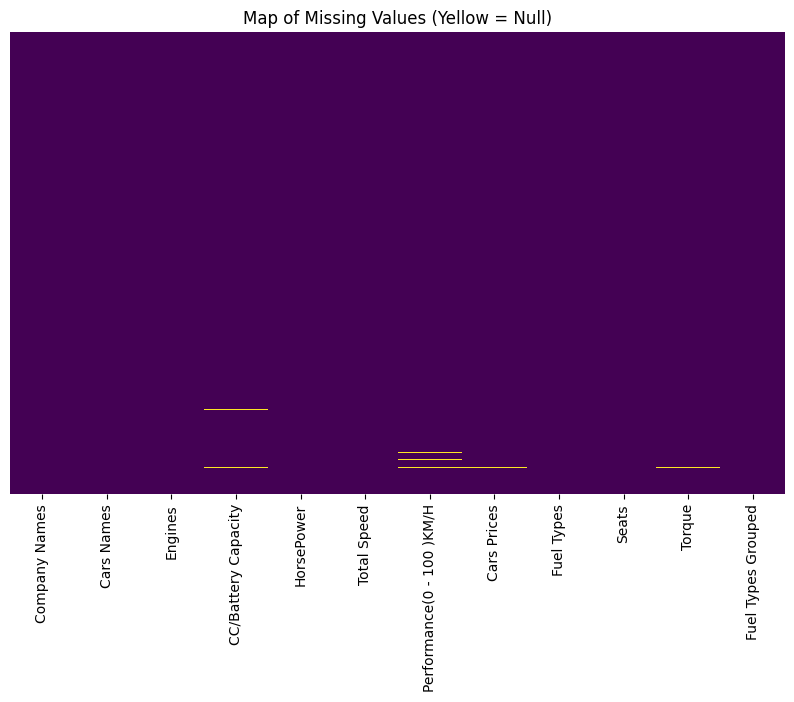

,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Seats,Torque
0,3990.0,963.0,340.0,2.5,1.0,2.0,800.0
1,6749.0,563.0,250.0,5.3,460.0,5.0,900.0
2,1.0,70.0,165.0,10.5,12.0,5.0,100.0
3,3.0,630.0,250.0,3.2,161.0,4.0,900.0
4,5.0,602.0,320.0,3.6,253.0,2.0,560.0
...,...,...,...,...,...,...,...
1213,2487.0,240.0,180.0,7.6,43.0,5.0,239.0
1214,2393.0,326.0,180.0,6.8,50.0,7.0,630.0
1215,1987.0,169.0,190.0,8.0,25.0,5.0,190.0
1216,1798.0,140.0,180.0,7.9,33.0,5.0,190.0


In [7]:
#Converting string values to numbers
def extract_numeric(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    m = re.findall(r"[-+]?\d*\.?\d+", s)
    if not m:
        return np.nan
    return float(m[0])

numeric_cols_raw = [
    "CC/Battery Capacity",
    "HorsePower",
    "Total Speed",
    "Performance(0 - 100 )KM/H",
    "Cars Prices",
    "Seats",
    "Torque"
]

for col in numeric_cols_raw:
    if col in df.columns:
        df[col] = df[col].apply(extract_numeric)
        
#display of missing data
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Map of Missing Values (Yellow = Null)')
plt.show()

#list of numeric columns
numeric_cols = df.select_dtypes(include=["float", "int"]).columns.tolist()

#Removal and replacement of columns with null values, as they are insignificant
df[numeric_cols].fillna(df[numeric_cols].mean())
df[numeric_cols].dropna()

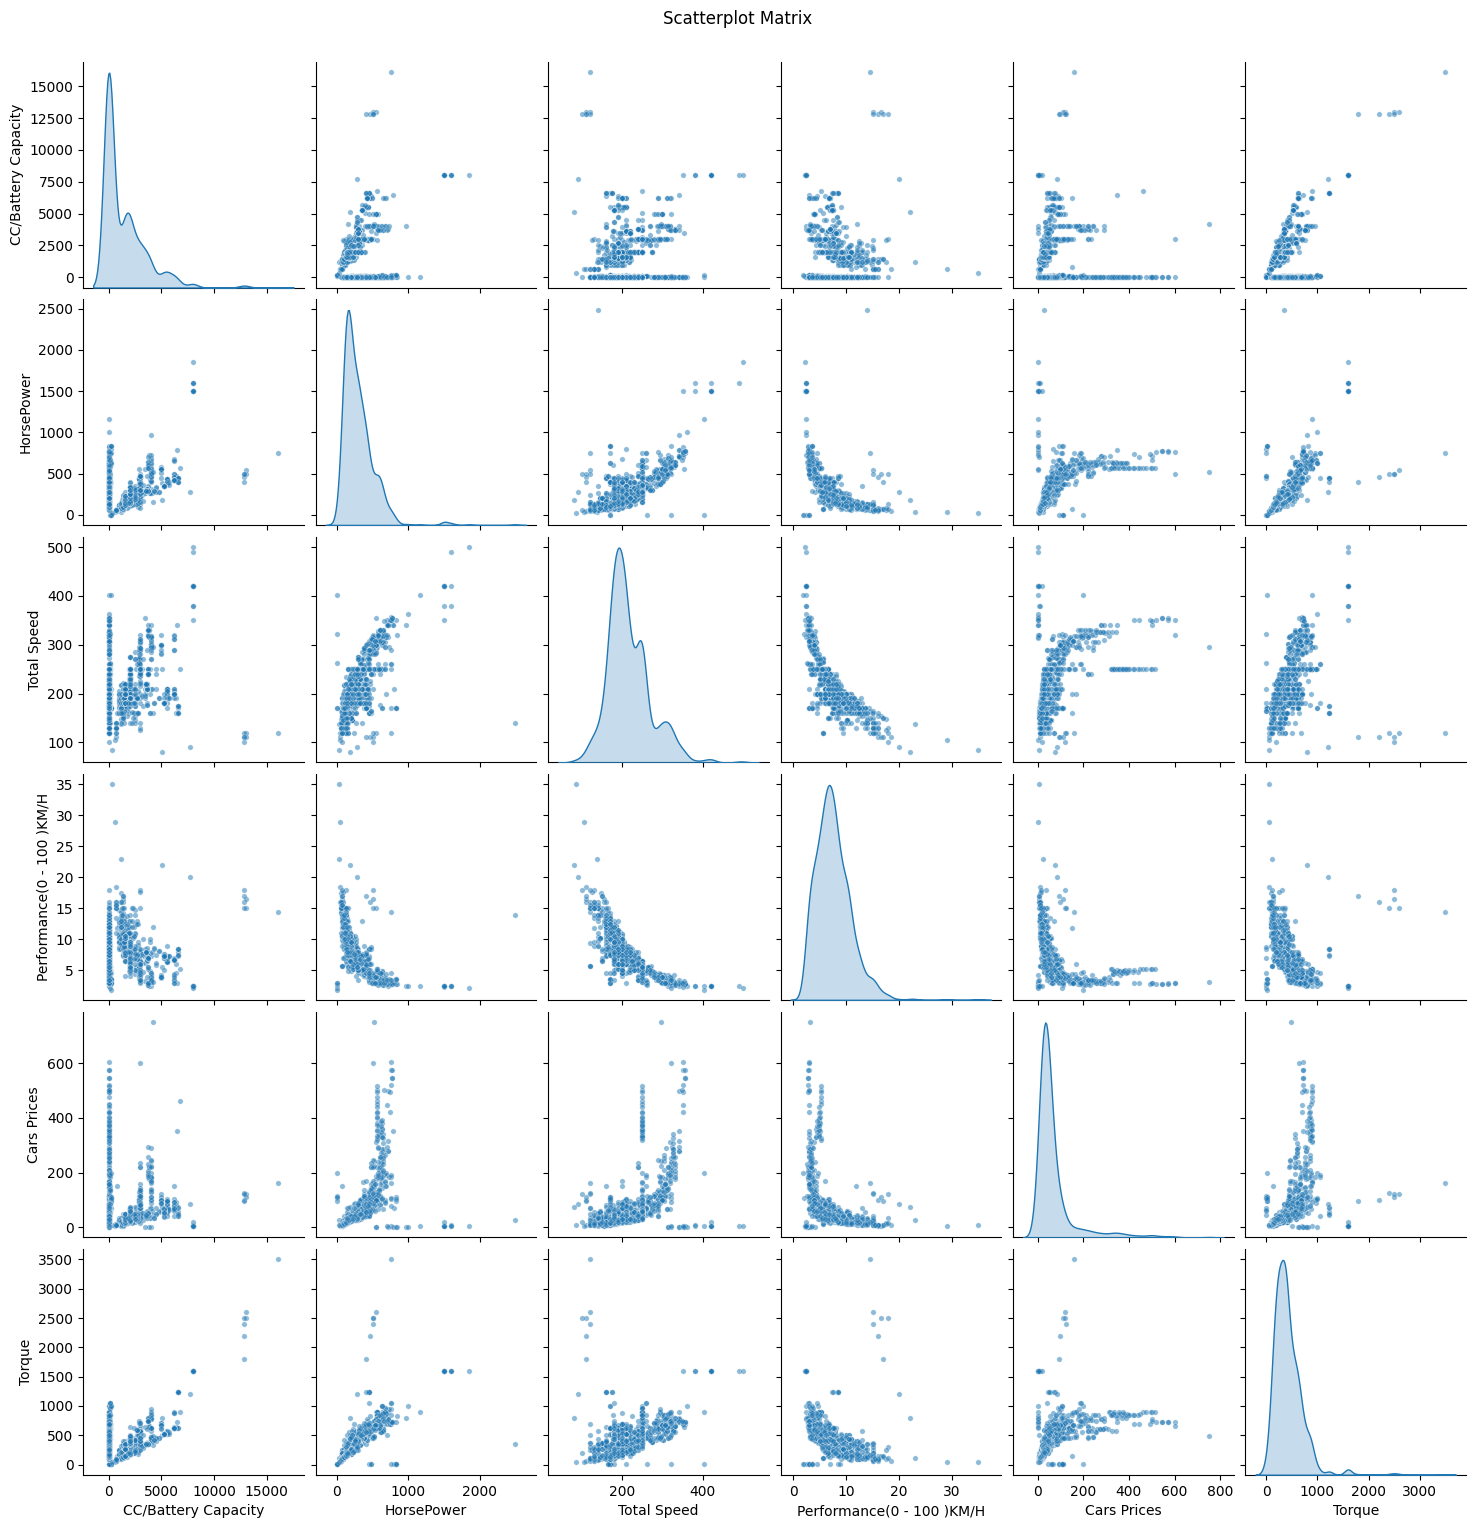

In [8]:
#columns to be displayed as a chart
cols_to_plot = ["CC/Battery Capacity","HorsePower","Total Speed","Performance(0 - 100 )KM/H","Cars Prices", "Torque"]

#matrix scatter plot
g = sns.pairplot(df[cols_to_plot], diag_kind='kde', plot_kws={'alpha': 0.5, 's': 15}, diag_kws={'fill': True}, height=2.5)

g.figure.suptitle('Scatterplot Matrix', y=1.02)
plt.show()


OUTLIERS COUNT:
CC/Battery Capacity 92
HorsePower 22
Total Speed 13
Performance(0 - 100 )KM/H 23
Cars Prices 129
Seats 322
Torque 26

Shape after outlier removal: (619, 12)

CORRELATION WITHOUT OUTLIERS:
                            CC/Battery Capacity  HorsePower  Total Speed  \
CC/Battery Capacity                   1.000000    0.110168     0.225180   
HorsePower                            0.110168    1.000000     0.594539   
Total Speed                           0.225180    0.594539     1.000000   
Performance(0 - 100 )KM/H            -0.075848   -0.781875    -0.714895   
Cars Prices                           0.168474    0.804702     0.612579   
Seats                                      NaN         NaN          NaN   
Torque                                0.084406    0.863933     0.526858   

                           Performance(0 - 100 )KM/H  Cars Prices  Seats  \
CC/Battery Capacity                        -0.075848     0.168474    NaN   
HorsePower                               

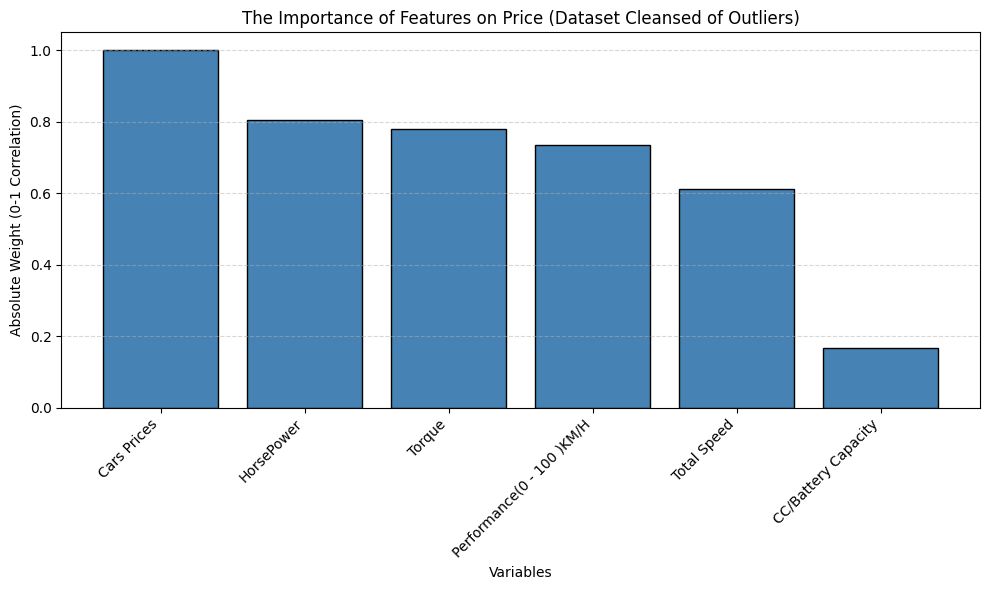

In [9]:
#find the outliers
numeric_cols = df.select_dtypes(include=["float", "int"]).columns.tolist()

def find_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return df[(df[col] < low) | (df[col] > high)]

print("\nOUTLIERS COUNT:")
for col in numeric_cols:
    print(col, len(find_outliers(col)))

df_no_out = df.copy()
for col in numeric_cols:
    Q1 = df_no_out[col].quantile(0.25)
    Q3 = df_no_out[col].quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df_no_out = df_no_out[(df_no_out[col] >= low) & (df_no_out[col] <= high)]

print("\nShape after outlier removal:", df_no_out.shape)

corr_no_out = df_no_out[numeric_cols].corr()
corr_price = df_no_out[numeric_cols].corr()["Cars Prices"].abs().sort_values(ascending=False)
print("\nCORRELATION WITHOUT OUTLIERS:\n", corr_no_out)

plt.figure(figsize=(10, 6))
plt.bar(corr_price.index, corr_price.values, color='steelblue', edgecolor='black')

plt.title('The Importance of Features on Price (Dataset Cleansed of Outliers)')
plt.ylabel('Absolute Weight (0-1 Correlation)')
plt.xlabel('Variables')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

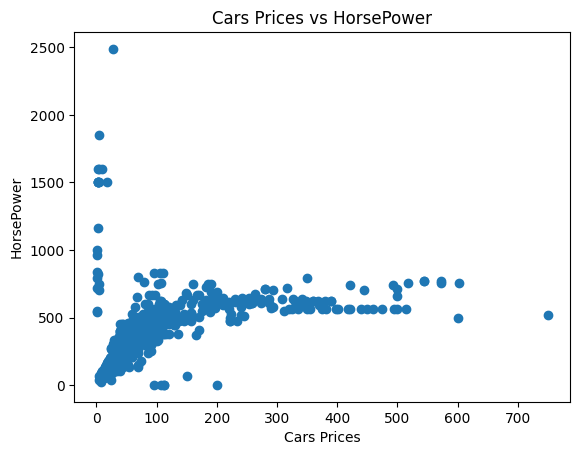

In [10]:
plt.figure()
plt.scatter(df["Cars Prices"], df["HorsePower"])
plt.xlabel("Cars Prices")
plt.ylabel("HorsePower")
plt.title("Cars Prices vs HorsePower")
plt.show()

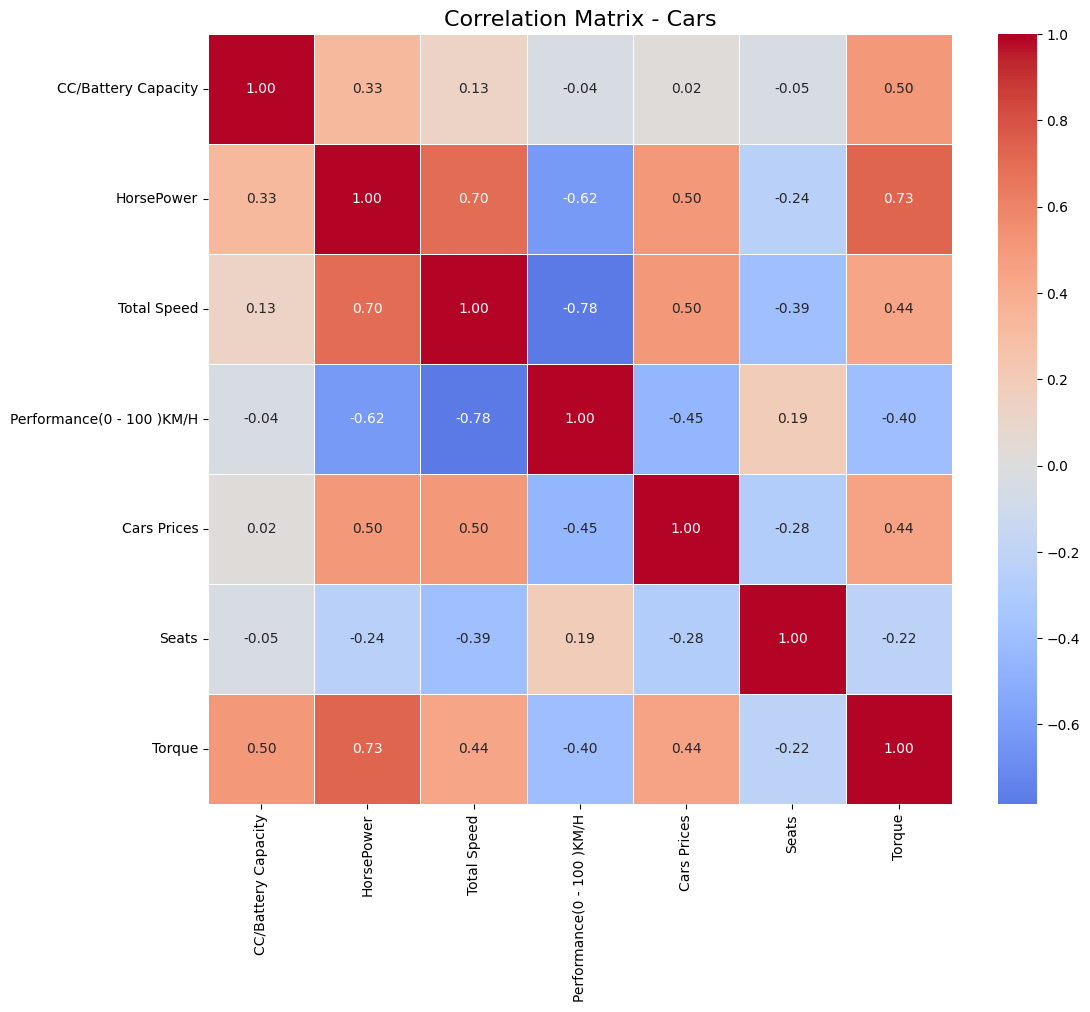

In [11]:
#Correlation matrix
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    fmt=".2f"
)

plt.title('Correlation Matrix - Cars', fontsize=16)
plt.show()

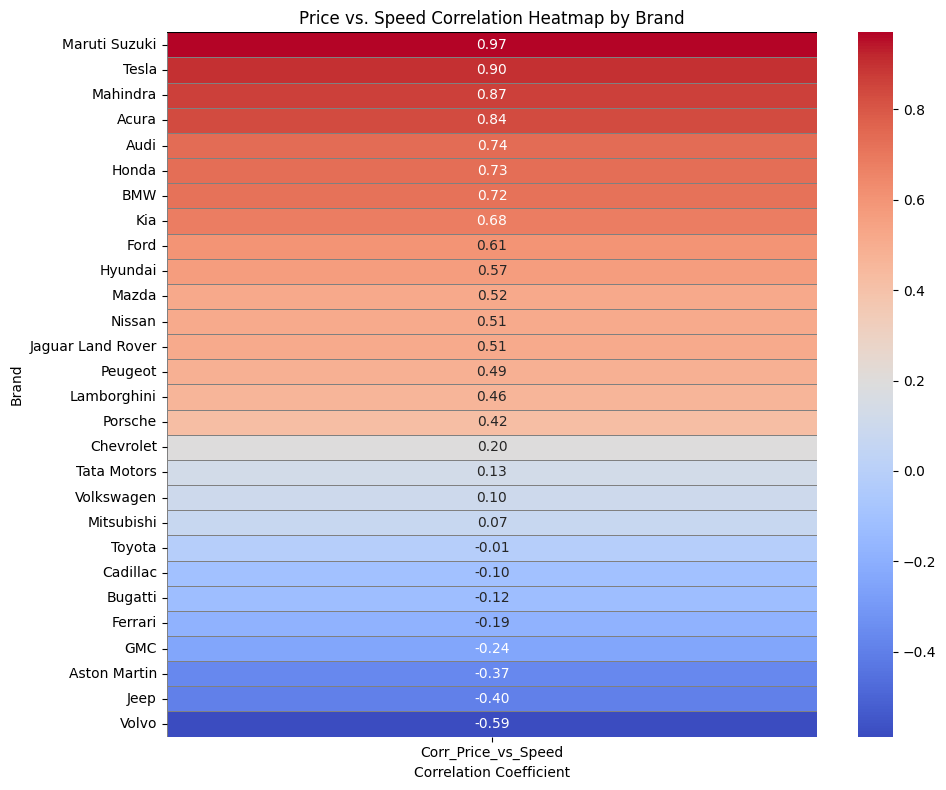

In [12]:
#correlation matrix between company and price
correlations = {}
for brand in df['Company Names'].unique():
    subset = df[df['Company Names'] == brand]
    if subset['Cars Prices'].nunique() > 1 and subset['Total Speed'].nunique() > 1:
        corr = subset['Cars Prices'].corr(subset['Total Speed'])
        correlations[brand] = corr

corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Corr_Price_vs_Speed'])
corr_df = corr_df.sort_values('Corr_Price_vs_Speed', ascending=False)

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_df[['Corr_Price_vs_Speed']],
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='gray'
)

plt.title('Price vs. Speed Correlation Heatmap by Brand')
plt.ylabel('Brand')
plt.xlabel('Correlation Coefficient')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [13]:
#Creating combined columns
df_eng = df.copy()
#Pricing for chairs
df_eng['Price_seats'] = df_eng['Cars Prices'] / df_eng['Seats']

#Creating a torque-speed relationship
df_eng['Torque_velocità'] = df_eng['Torque'] / df_eng['Total Speed']

#Let's take a look at the new columns
print(df_eng[['Torque_velocità', 'Price_seats']])

      Torque_velocità  Price_seats
0            2.352941     0.500000
1            3.600000    92.000000
2            0.606061     2.400000
3            3.600000    40.250000
4            1.750000   126.500000
...               ...          ...
1213         1.327778     8.600000
1214         3.500000     7.142857
1215         1.000000     5.000000
1216         1.055556     6.600000
1217         1.105000     5.800000

[1218 rows x 2 columns]


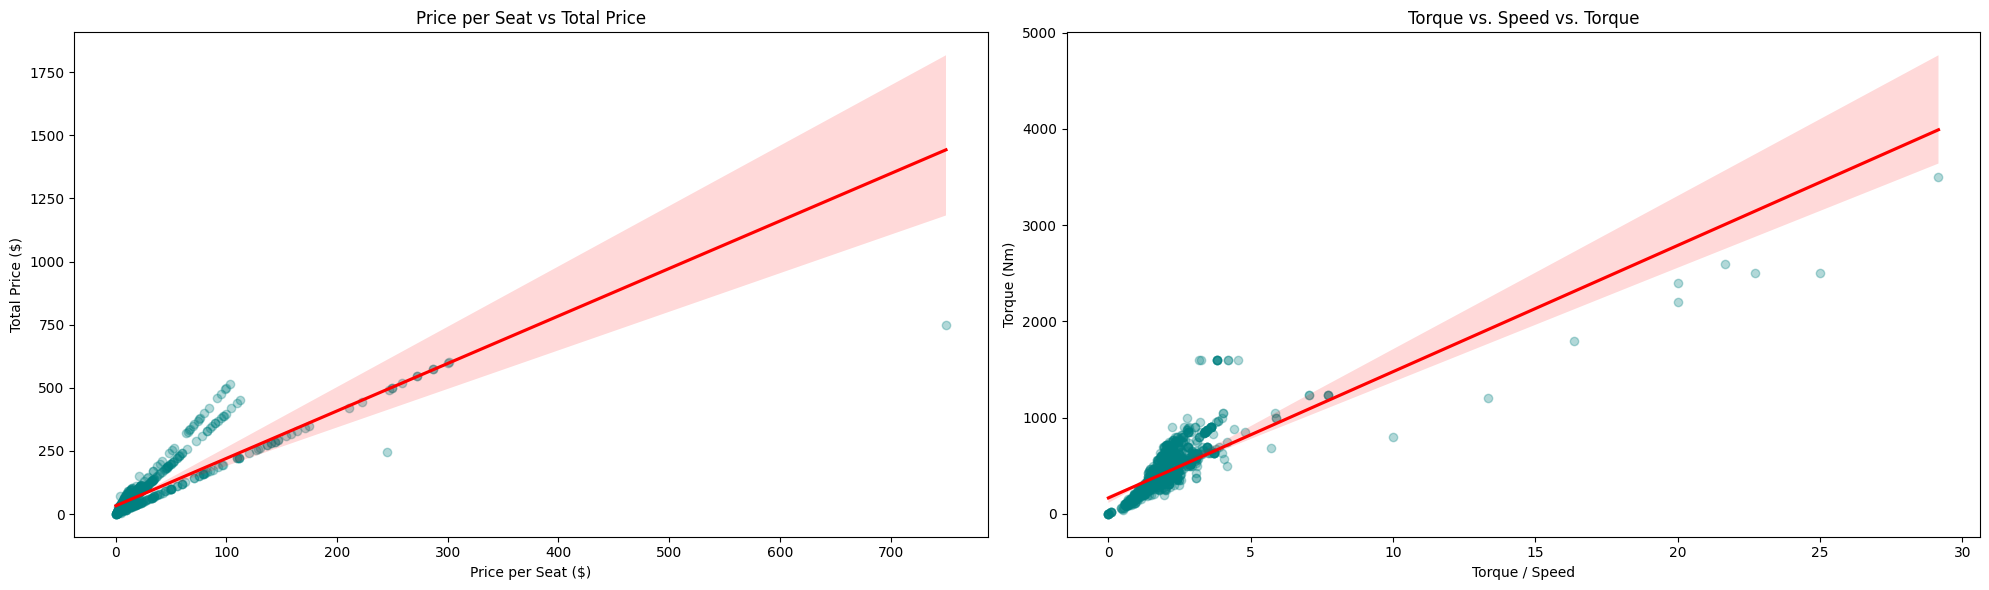

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

#Price per seat vs. total price
sns.regplot(x='Price_seats', y='Cars Prices', data=df_eng, ax=axes[0],
            scatter_kws={'alpha':0.3, 'color':'teal'},
            line_kws={'color':'red'})
axes[0].set_title('Price per Seat vs Total Price')
axes[0].set_xlabel('Price per Seat ($)')
axes[0].set_ylabel('Total Price ($)')

#torque/velocità vs torque
sns.regplot(x='Torque_velocità', y='Torque', data=df_eng, ax=axes[1],
            scatter_kws={'alpha':0.3, 'color':'teal'},
            line_kws={'color':'red'})
axes[1].set_title('Torque vs. Speed vs. Torque')
axes[1].set_xlabel('Torque / Speed')
axes[1].set_ylabel('Torque (Nm)')

plt.tight_layout()
plt.show()

Top 5 compagnie più costose: ['Rolls-Royce', 'Lamborghini', 'Bentley', 'Ferrari', 'Aston Martin']
Company Names
Aston Martin    3.527273
Bentley         4.000000
Ferrari         3.033333
Lamborghini     3.037500
Rolls-Royce     4.910000
Name: Performance(0 - 100 )KM/H, dtype: float64


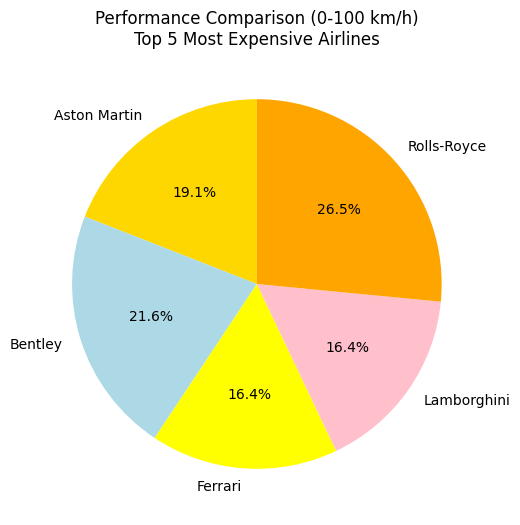

In [15]:
topB = (
    df.groupby("Company Names")["Cars Prices"]
      .mean()
      .sort_values(ascending=False)
      .head(5)
      .index
      .tolist()
)

print("Top 5 compagnie più costose:", topB)

df_topB = df[df["Company Names"].isin(topB)]

performance_by_brand = (
    df_topB.groupby("Company Names")["Performance(0 - 100 )KM/H"]
           .mean()
)

print(performance_by_brand)

plt.figure(figsize=(6,6))
plt.pie(
    performance_by_brand,
    labels=performance_by_brand.index,
    autopct='%1.1f%%',
    colors=['gold', 'lightblue','yellow','pink','orange'],
    startangle=90
)
plt.title('Performance Comparison (0-100 km/h)\nTop 5 Most Expensive Airlines')
plt.show()

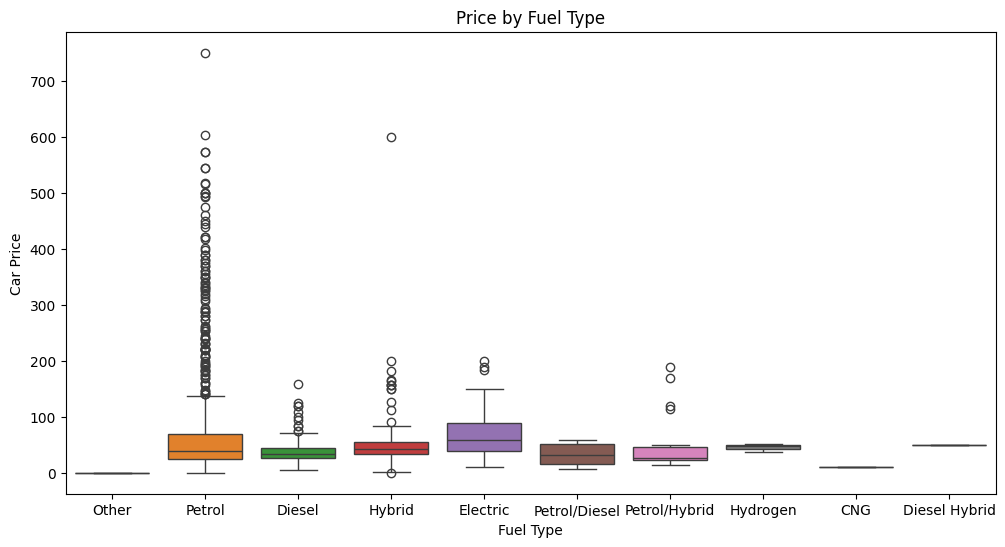

In [16]:
plt.figure(figsize=(12, 6))

# Price Boxplot 
sns.boxplot(x='Fuel Types Grouped', y='Cars Prices', data=df_eng, hue='Fuel Types Grouped', legend=False)
plt.title('Price by Fuel Type')
plt.ylabel('Car Price')
plt.xlabel('Fuel Type')
plt.show()

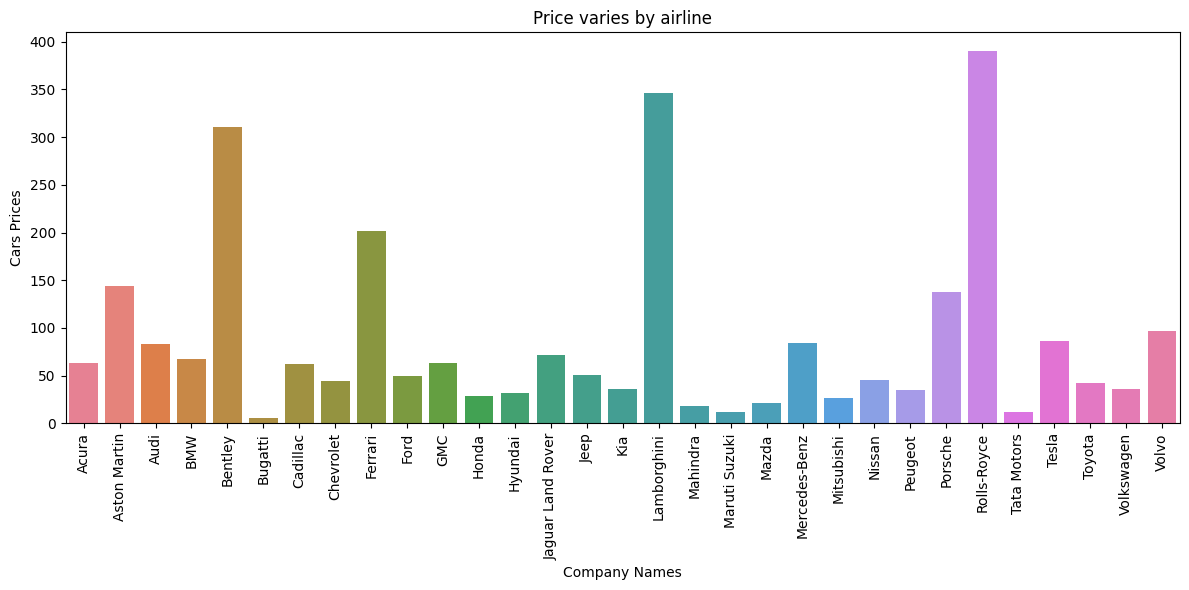

In [17]:
#data grouping
cars_stats = df_eng.groupby('Company Names')[['Cars Prices']].mean()

plt.figure(figsize=(12, 6))
plt.title('Price varies by airline')
sns.barplot(x=cars_stats.index, y=cars_stats['Cars Prices'], hue=cars_stats.index)
plt.xticks(rotation=90, ha='center')


plt.tight_layout()
plt.show()

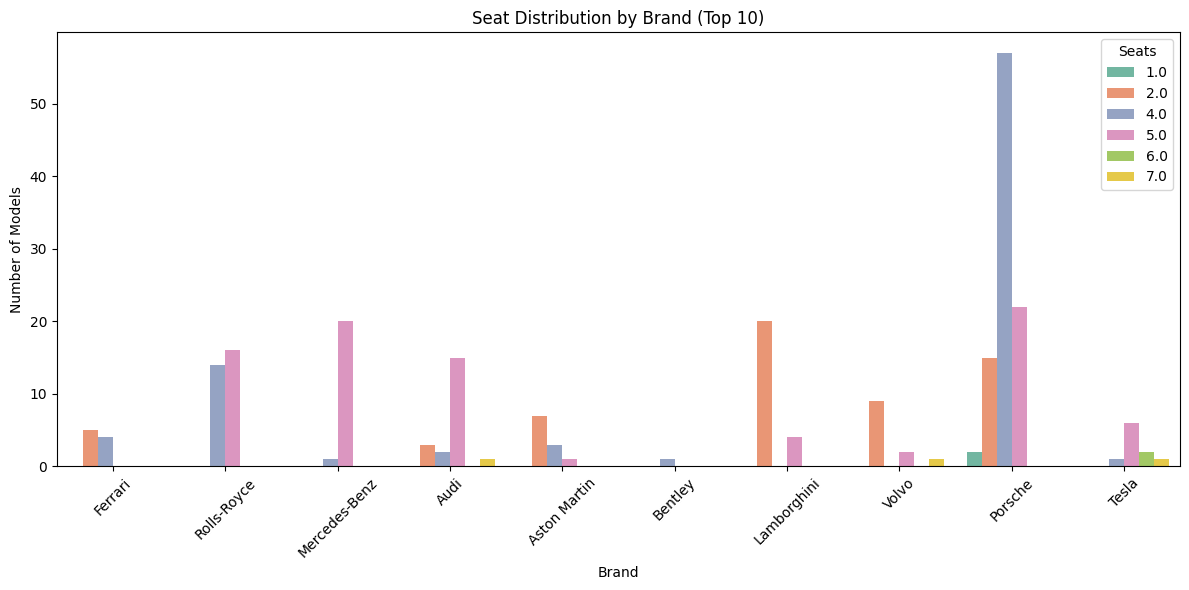

In [18]:
topBb = (
    df.groupby("Company Names")["Cars Prices"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .index
      .tolist()
)
df_top10 = df[df['Company Names'].isin(topBb)]

#Calculating the median number of seats by brand
seats_median = (
    df_top10.groupby('Company Names')['Seats']
    .median()
    .sort_values()
)

plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_top10,
    x='Company Names',
    hue='Seats',
    palette='Set2'
)

plt.title('Seat Distribution by Brand (Top 10)')
plt.xlabel('Brand')
plt.ylabel('Number of Models')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

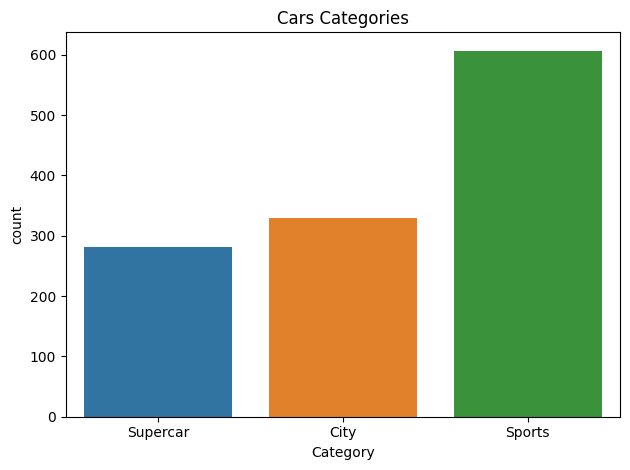

In [19]:
def category_hp(hp):
    if hp <= 150:
        return "City"
    elif hp <= 400:
        return "Sports"
    else:
        return "Supercar"

df["Category"] = df["HorsePower"].apply(category_hp)

#Cars Categories plot
plt.title('Cars Categories')
sns.countplot(data=df, x = "Category", hue="Category")
plt.tight_layout()
plt.show()


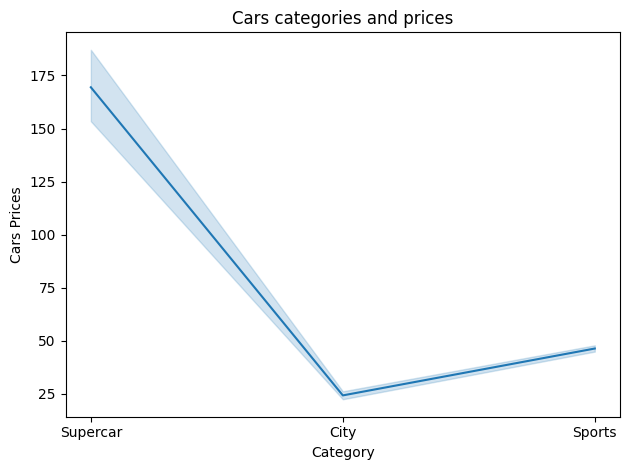

In [20]:
#Plot of cars categories and prices
plt.title('Cars categories and prices')
sns.lineplot(data=df, x = "Category", y="Cars Prices")
plt.tight_layout()
plt.show()